workflow which creats the memory from the given message (not a chatbot !)

In [14]:
import uuid
from typing import List
from pydantic import BaseModel,Field
from langchain_groq import ChatGroq
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage,AIMessage,HumanMessage

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore
from dotenv import load_dotenv
load_dotenv()

True

In [15]:
store = InMemoryStore()

In [16]:
llm_extractor = ChatGroq(model="llama-3.1-8b-instant")

In [17]:
# pydantic base model
class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[str] = Field(default_factory=list, description="Atomic user memories to store")

In [18]:
llm_with_structured = llm_extractor.with_structured_output(MemoryDecision)

In [22]:
def Remember(state:MessagesState, config:RunnableConfig, store:BaseStore) -> MessagesState:
    user_id = config['configurable']['user_id']

    namespace = ("user",user_id,"details")

    last_msg = state['messages'][-1].content

    decision:MemoryDecision = llm_with_structured.invoke([
        SystemMessage(content=("Extract LONG-TERM memories from the user's message.\n"
                    "Only store stable, user-specific info (identity, preferences, ongoing projects).\n"
                    "Do NOT store transient info.\n"
                    "Return should_write=false if nothing is worth storing.\n"
                    "Each memory should be a short atomic sentence.")),
        HumanMessage(content=last_msg)
        ])     #{'role':'user','content':last_msg} same
    
    if decision.should_write:
        for mem in decision.memories:
            store.put(namespace,str(uuid.uuid4()),{'data':mem})

    # IMPORTANT: we are NOT using memory, not even responding with the LLM.
    # We just return a fixed acknowledgement.
    return {"messages": [{"role": "assistant", "content": "Noted."}]}
                                                                       

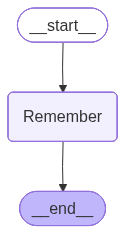

In [23]:
workflow = StateGraph(MessagesState)

workflow.add_node("Remember",Remember)

workflow.add_edge(START,"Remember")
workflow.add_edge("Remember",END)

graph = workflow.compile(store=store)

graph

In [29]:
config = {'configurable':{'user_id':'u1'}}

result = graph.invoke({"messages": {'role':'user','content':'my name is haroon'}},config=config)
print("Assistant:", result["messages"][-1].content)

Assistant: Noted.


In [30]:
res = graph.invoke({"messages": [{"role": "user", "content": "I am a AIDS student at mjcet college"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [32]:
namespace = ('user','u1','details')
items = store.search(namespace)

memories = "\n".join(item.value.get('data','') for item in items)
print(memories)

My name is haroon
I am an AIDS student
I am studying at MJCET college
my name is haroon


duplication removed 
Chatbot Creating New Memories(without Duplication)

In [54]:
import uuid
from typing import List
from pydantic import BaseModel,Field
from langchain_groq import ChatGroq
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage,AIMessage,HumanMessage

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore
from dotenv import load_dotenv
load_dotenv()

True

In [55]:
store = InMemoryStore()
llm_extractor = ChatGroq(model="llama-3.1-8b-instant")

In [56]:
# pydantic base model
class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory as a short sentence")
    is_new: bool = Field(description="True if this memory is NEW and should be stored. False if duplicate/already known.")

class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[MemoryItem] = Field(default_factory=list, description="Atomic user memories to store")

In [57]:
llm_with_structured = llm_extractor.with_structured_output(MemoryDecision)

In [58]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return an empty list."""

In [59]:
def chat_creates_memory_node(state: MessagesState, config: RunnableConfig, store: BaseStore):

    user_id = config["configurable"]["user_id"]

    namespace = ("user", user_id, "details")

    # A) Load existing memories
    existing_items = store.search(namespace)
    existing_texts = [it.value.get("data", "") for it in existing_items if it.value.get("data",'')]
    user_details_content = "\n".join(f"- {t}" for t in existing_texts) if existing_texts else "(empty)"

    # B) Latest user message
    last_text = state["messages"][-1]

    # C) LLM extracts memories + marks new vs duplicate
    decision: MemoryDecision = llm_with_structured.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=user_details_content)),
            {"role": "user", "content": f"USER MESSAGE:\n{last_text}"},
        ]
    )

    # D) Store ONLY new memories
    if decision.should_write: 
        for mem in decision.memories:
            if mem.is_new: #if true then only add karo store me 
                store.put(namespace, str(uuid.uuid4()), {"data": mem.text})

    return {"messages": [{"role": "assistant", "content": "Noted."}]}

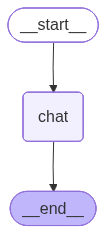

In [60]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_creates_memory_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)
graph

In [66]:
config = {'configurable':{'user_id':'u1'}}
r1 = graph.invoke({"messages": [{"role": "user", "content": "My name is haroon"}]}, config)
print("Assistant:", r1["messages"][-1].content)

Assistant: Noted.


In [67]:
for it in store.search(("user",'u1','details')):
    print(it.value.get('data',''))

User named haroon
My name is haroon
